# Q1) Normalized fragment length frequency
## i)Fragment length frequency:

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import defaultdict

data = pd.read_csv('query.bed', sep='\t', header=None)

<ipython-input-22-b8dcf9ab2a8e>:7: DtypeWarning: Columns (3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/content/query.bed', sep='\t', header=None)


Loads the .bed file with no headers and tab-separated columns into a DataFrame named data.

In [23]:
lengths = data[2] - data[1]

Calculates fragment lengths by subtracting start (column 1) from end (column 2) for each row.

In [24]:
cnt = defaultdict(int)
for i in lengths:
    cnt[i] += 1

Counts occurrences of each fragment length using a dictionary.

In [25]:
total = np.sum(list(cnt.values()))

Calculates the total number of fragments (sum of all fragment length counts).

In [26]:
normalized = {}
for frag_len, count in cnt.items():
    normalized[frag_len] = count / total

Normalizes the frequency of each fragment length by dividing each count by the total number of fragments.

In [27]:
sorted_lengths = sorted(normalized.items())
length_vals = [item[0] for item in sorted_lengths]
freq_vals = [item[1] for item in sorted_lengths]

Sorts the data by fragment length and separates it into two lists: lengths and normalized frequencies.

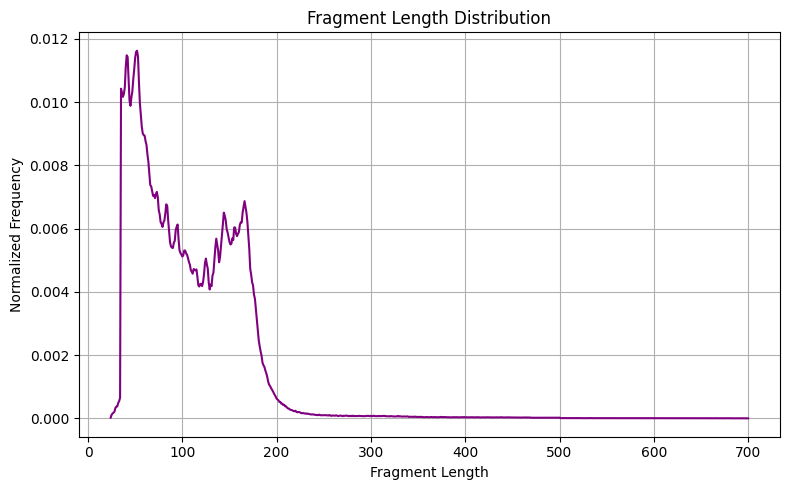

In [28]:
plot_data = pd.DataFrame({
    'Length': length_vals,
    'Frequency': freq_vals
})

plt.figure(figsize=(8, 5))
plt.plot(plot_data['Length'], plot_data['Frequency'], color='purple')
plt.xlabel('Fragment Length')
plt.ylabel('Normalized Frequency')
plt.title('Fragment Length Distribution')
plt.grid(True)
plt.tight_layout()
plt.show()

Plots the normalized distribution of fragment lengths.

X-axis: Fragment length (in base pairs)

Y-axis: Normalized frequency (unitless)


# ii) Rescaling:
# Rescaling one (query) to the other (reference).

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ref = pd.read_csv('reference.hist', sep='\t', header=None, names=['Len', 'Freq'])

query = pd.read_csv('query.bed', sep='\t', header=None)
frag_len = query[2] - query[1]
qdf = pd.DataFrame({'Len': frag_len})

<ipython-input-29-ddf533febb4b>:7: DtypeWarning: Columns (3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  query = pd.read_csv('query.bed', sep='\t', header=None)


### Fragment Length Comparison Between Reference and Query

1. **Load Reference Histogram**  
   The `reference.hist` file is loaded into a DataFrame named `ref` with the following columns:
   - `Len`: Fragment length bin (in base pairs).
   - `Freq`: Normalized frequency of fragment lengths, where all values sum to 1.

2. **Load Query BED File and Compute Fragment Lengths**  
   The query BED file is read, and fragment lengths are calculated as:
   - `length = end - start`  
   for each row in the BED file.

3. **Create Query Fragment DataFrame**  
   A new DataFrame `qdf` is created to store the calculated fragment lengths for all query fragments.


In [30]:
bins = np.append(ref['Len'].values, ref['Len'].values[-1] + 1)
qdf['bin'] = pd.cut(qdf['Len'], bins=bins, labels=False, include_lowest=True)

We create bin edges using the ref['Len'] values. The last bin includes an extra value to close the range.

Each query fragment is assigned to a bin based on its length using pd.cut().

In [31]:
samples = []
np.random.seed(42)

for i in range(len(ref)):
    bin_data = qdf[qdf['bin'] == i]
    if bin_data.empty:
        continue

    frac = ref.loc[i, 'Freq']
    n = int(frac * len(qdf) * 0.3346807)

    if n < len(bin_data):
        chosen = bin_data.sample(n=n, replace=False)
    else:
        chosen = bin_data

    samples.append(chosen)

sub = pd.concat(samples)

### Sampling Query Fragments Based on Reference Distribution

1. **Initialization**  
   - A list named `samples` is initialized to store the sampled fragments.
   - A random seed is set using `np.random.seed()` to ensure reproducibility of the results.

2. **Iterate Through Each Length Bin**  
   For each length bin in the reference histogram:
   - Retrieve all query fragments in that bin and store them in `bin_data`.
   - If `bin_data` is empty (i.e., no fragments in that bin), skip to the next bin.

3. **Compute Sample Size**  
   - Determine the number of fragments to sample using the formula:  
     `n = (reference fraction for the bin) * (total number of query fragments) * 0.4`
   - This scales the sampling size according to the reference distribution and uses a 40% sampling rate.

4. **Sample Fragments**  
   - If `bin_data` has at least `n` fragments, sample `n` without replacement.
   - If not enough fragments are available, use all of them.

5. **Concatenate Sampled Fragments**  
   - All sampled fragments are collected into the `samples` list.
   - Finally, they are concatenated into a single DataFrame named `sub`.


In [32]:
q_hist, _ = np.histogram(qdf['Len'], bins=bins)
q_hist = q_hist / q_hist.sum()

sub_hist, _ = np.histogram(sub['Len'], bins=bins)
sub_hist = sub_hist / sub_hist.sum()

We calculate histograms for:

The original query (q_hist)

The subsampled query (sub_hist)

Both are normalized so that the sum of all bins equals 1 (i.e., probability distribution).

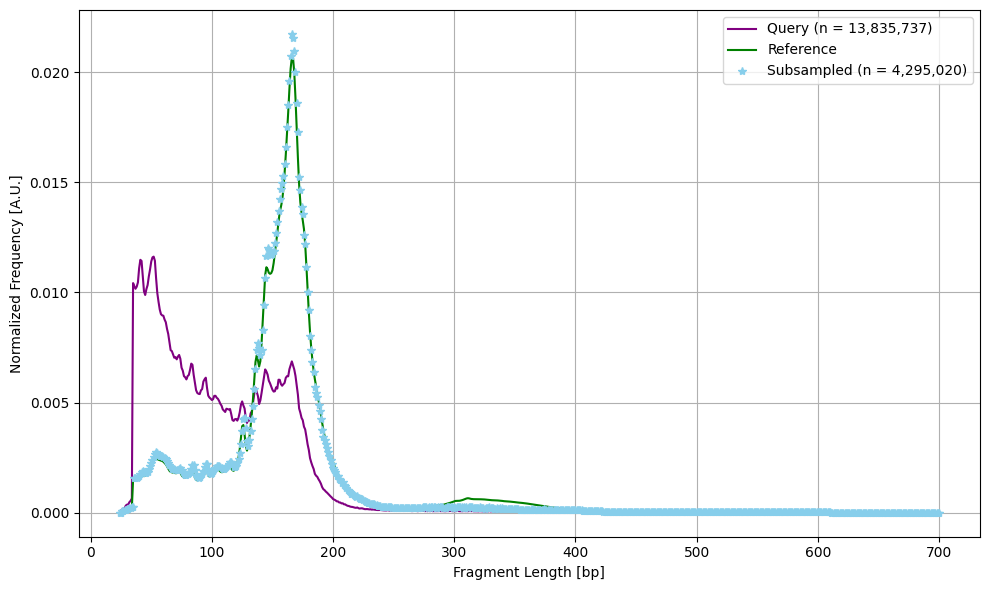

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(ref['Len'], q_hist, label=f'Query (n = {len(qdf):,})', color='purple')
plt.plot(ref['Len'], ref['Freq'], label='Reference', color='green')
plt.plot(ref['Len'], sub_hist, label=f'Subsampled (n = {len(sub):,})', marker='*', linestyle='None', color='skyblue')
plt.xlabel('Fragment Length [bp]')
plt.ylabel('Normalized Frequency [A.U.]')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

We plot the three distributions:

The original query in purple

The reference in green

The subsampled query in blue (as points with *)

The x-axis shows fragment length, and the y-axis shows normalized frequency.